In [82]:
df = pd.read_csv("data/insurance.csv")

In [83]:
df.to_csv("data/cleaned_data.csv", index=False)

In [84]:
df = pd.read_csv("data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [85]:
# Feature Matrix
X = df.drop("charges", axis=1)

# Regression Target
y_reg = df["charges"]

# Binary Classification Target
y_clf = (df["charges"] > df["charges"].median()).astype(int)

print("Regression Target Shape:", y_reg.shape)
print("Classification Target Shape:", y_clf.shape)

print("\nClassification Class Distribution:")
print(y_clf.value_counts())

Regression Target Shape: (1338,)
Classification Target Shape: (1338,)

Classification Class Distribution:
charges
1    669
0    669
Name: count, dtype: int64


In [86]:
X = pd.get_dummies(X, drop_first=True)

print(X.head())
print("\nShape after encoding:", X.shape)

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

Shape after encoding: (1338, 8)


In [87]:
from sklearn.model_selection import train_test_split

In [88]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [89]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

In [90]:
from sklearn.preprocessing import StandardScaler

In [91]:
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [92]:
scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)

X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [93]:
print(X_train_reg_scaled.shape)
print(X_test_reg_scaled.shape)

print(X_train_clf_scaled.shape)
print(X_test_clf_scaled.shape)

(1070, 8)
(268, 8)
(1070, 8)
(268, 8)


In [94]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [95]:
lr_model = LinearRegression()

lr_model.fit(X_train_reg_scaled, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [96]:
y_pred_lr = lr_model.predict(X_test_reg_scaled)

In [97]:
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MSE :", mse_lr)
print("R² Score :", r2_lr)

Linear Regression Results
-------------------------
MSE : 33596915.85136149
R² Score : 0.7835929767120722


In [98]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef_df

,Feature,Coefficient
0,age,3614.975415
1,bmi,2036.228123
2,children,516.890247
3,sex_male,-9.293101
4,smoker_yes,9558.481409
5,region_northwest,-158.140981
6,region_southeast,-290.157047
7,region_southwest,-349.110678


In [99]:
coef_df["Absolute"] = coef_df["Coefficient"].abs()

top3 = coef_df.sort_values(
    by="Absolute",
    ascending=False
).head(3)

print(top3)

      Feature  Coefficient     Absolute
4  smoker_yes  9558.481409  9558.481409
0         age  3614.975415  3614.975415
1         bmi  2036.228123  2036.228123


In [100]:
from sklearn.linear_model import Ridge

In [101]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_reg_scaled, y_train_reg)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [102]:
y_pred_ridge = ridge.predict(X_test_reg_scaled)

In [103]:
mse_ridge = mean_squared_error(
    y_test_reg,
    y_pred_ridge
)

r2_ridge = r2_score(
    y_test_reg,
    y_pred_ridge
)

print("Ridge Regression")
print("----------------")
print("MSE :", mse_ridge)
print("R² :", r2_ridge)

Ridge Regression
----------------
MSE : 33604973.53996333
R² : 0.7835410749121384


In [104]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse_lr,
        mse_ridge
    ],
    "R2 Score": [
        r2_lr,
        r2_ridge
    ]
})

comparison

,Model,MSE,R2 Score
0,Linear Regression,3.359692e+07,0.783593
1,Ridge Regression,3.360497e+07,0.783541


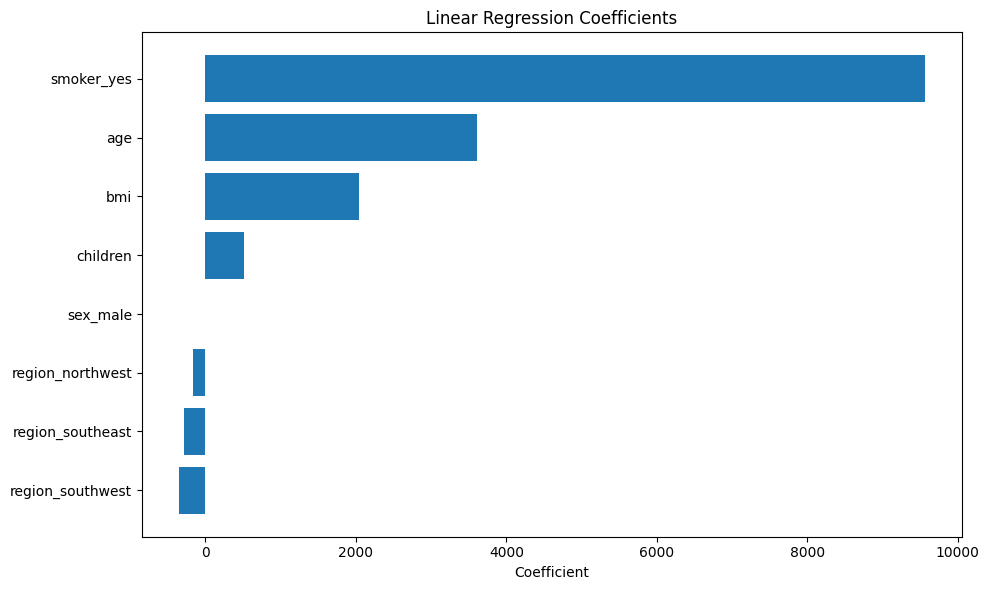

In [105]:
import matplotlib.pyplot as plt

coef_plot = coef_df.sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10,6))

plt.barh(
    coef_plot["Feature"],
    coef_plot["Coefficient"]
)

plt.title("Linear Regression Coefficients")

plt.xlabel("Coefficient")

plt.tight_layout()

plt.savefig("plots/feature_importance.png")

plt.show()

In [106]:
print("Training Set Class Distribution:")
print(y_train_clf.value_counts())

print("\nPercentage Distribution:")
print(y_train_clf.value_counts(normalize=True) * 100)

Training Set Class Distribution:
charges
1    547
0    523
Name: count, dtype: int64

Percentage Distribution:
charges
1    51.121495
0    48.878505
Name: proportion, dtype: float64


In [107]:
from sklearn.linear_model import LogisticRegression

In [108]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_clf_scaled, y_train_clf)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [109]:
y_pred_clf = log_model.predict(X_test_clf_scaled)

y_prob = log_model.predict_proba(X_test_clf_scaled)[:, 1]

In [110]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [111]:
print("Confusion Matrix")
print(confusion_matrix(y_test_clf, y_pred_clf))

print("\nClassification Report")
print(classification_report(y_test_clf, y_pred_clf))

print("Accuracy :", accuracy_score(y_test_clf, y_pred_clf))
print("Precision:", precision_score(y_test_clf, y_pred_clf))
print("Recall   :", recall_score(y_test_clf, y_pred_clf))
print("F1 Score :", f1_score(y_test_clf, y_pred_clf))

Confusion Matrix
[[132  14]
 [  9 113]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       146
           1       0.89      0.93      0.91       122

    accuracy                           0.91       268
   macro avg       0.91      0.92      0.91       268
weighted avg       0.92      0.91      0.91       268

Accuracy : 0.914179104477612
Precision: 0.889763779527559
Recall   : 0.9262295081967213
F1 Score : 0.9076305220883534


In [112]:
from sklearn.metrics import roc_curve, roc_auc_score

In [113]:
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob)

auc = roc_auc_score(y_test_clf, y_prob)

print("AUC:", auc)

AUC: 0.9591848192229957


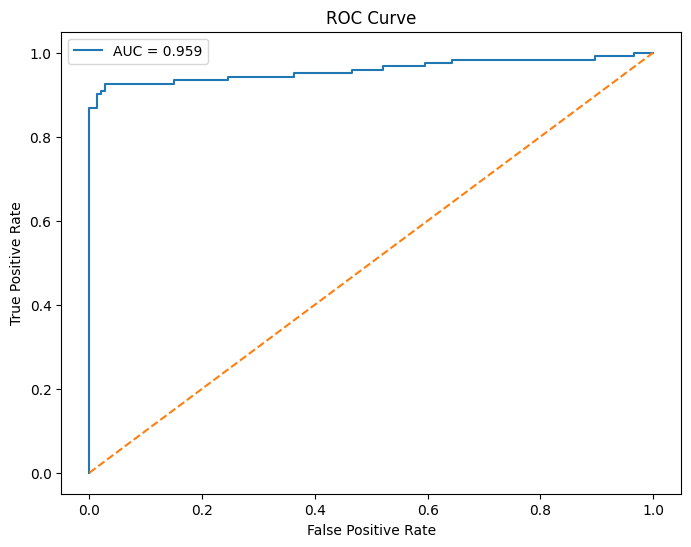

In [114]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("plots/roc_curve.png")

plt.show()

In [115]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    p = precision_score(y_test_clf, pred)

    r = recall_score(y_test_clf, pred)

    f = f1_score(y_test_clf, pred)

    results.append([t, p, r, f])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.3,0.760000,0.934426,0.838235
1,0.4,0.826087,0.934426,0.876923
2,0.5,0.889764,0.926230,0.907631
3,0.6,0.941667,0.926230,0.933884
4,0.7,1.000000,0.868852,0.929825


In [116]:
log_model_reg = LogisticRegression(C=0.01, max_iter=1000)

log_model_reg.fit(X_train_clf_scaled, y_train_clf)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mu

In [117]:
y_pred_reg = log_model_reg.predict(X_test_clf_scaled)

y_prob_reg = log_model_reg.predict_proba(X_test_clf_scaled)[:,1]

In [118]:
precision_reg = precision_score(y_test_clf, y_pred_reg)

recall_reg = recall_score(y_test_clf, y_pred_reg)

f1_reg = f1_score(y_test_clf, y_pred_reg)

auc_reg = roc_auc_score(y_test_clf, y_prob_reg)

print("Precision :", precision_reg)
print("Recall :", recall_reg)
print("F1 :", f1_reg)
print("AUC :", auc_reg)

Precision : 0.875968992248062
Recall : 0.9262295081967213
F1 : 0.900398406374502
AUC : 0.9562654390298676


In [119]:
comparison_logistic = pd.DataFrame({

    "Model":[
        "Baseline (C=1.0)",
        "Regularized (C=0.01)"
    ],

    "Precision":[
        precision_score(y_test_clf,y_pred_clf),
        precision_reg
    ],

    "Recall":[
        recall_score(y_test_clf,y_pred_clf),
        recall_reg
    ],

    "F1":[
        f1_score(y_test_clf,y_pred_clf),
        f1_reg
    ],

    "AUC":[
        roc_auc_score(y_test_clf,y_prob),
        auc_reg
    ]

})

comparison_logistic

,Model,Precision,Recall,F1,AUC
0,Baseline (C=1.0),0.889764,0.92623,0.907631,0.959185
1,Regularized (C=0.01),0.875969,0.92623,0.900398,0.956265


In [120]:
import numpy as np

bootstrap_diffs = []

np.random.seed(42)

for i in range(500):

    idx = np.random.choice(
        len(y_test_clf),
        size=len(y_test_clf),
        replace=True
    )

    y_true = y_test_clf.iloc[idx]

    prob1 = y_prob[idx]

    prob2 = y_prob_reg[idx]

    auc1 = roc_auc_score(y_true, prob1)

    auc2 = roc_auc_score(y_true, prob2)

    bootstrap_diffs.append(auc1 - auc2)

In [121]:
import joblib

In [122]:
joblib.dump(lr_model,"models/linear_regression.pkl")

joblib.dump(ridge,"models/ridge_regression.pkl")

joblib.dump(log_model,"models/logistic_regression.pkl")

joblib.dump(log_model_reg,"models/logistic_regression_regularized.pkl")

['models/logistic_regression_regularized.pkl']

In [123]:
comparison.to_csv(
    "models/regression_comparison.csv",
    index=False
)

comparison_logistic.to_csv(
    "models/logistic_comparison.csv",
    index=False
)

threshold_df.to_csv(
    "models/threshold_results.csv",
    index=False
)